In [ ]:
!pip install --upgrade --force-reinstall \
    "torch==2.5.1" \
    "transformers==4.46.3" \
    "datasets==3.1.0" \
    "pyarrow==18.1.0" \
    "accelerate>=0.26.0" \
    "sentencepiece" \
    "protobuf" \
    "shap"

In [2]:
import os
import re
import json
import random
import string
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import shap
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset
from IPython.display import HTML, display
import html

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
SHAP_BATCH_SIZE = 8

DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SHAP config search settings
QUANTILE_VALUES = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

# Ablation settings
ABLATION_MODE = "mask"

# Output
BASE_DIR = Path("results")
OUTPUT_DIR = BASE_DIR / "shap_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

Pipeline device: 0
Torch device: cuda


In [4]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)
pipe

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


In [5]:
ds = load_dataset(DATASET_NAME)

train_df_raw = ds["train"].to_pandas()
val_df_raw = ds["validation"].to_pandas()
test_df_raw = ds["test"].to_pandas()


def attach_split(df, split_name):
    """Add a split column before creating global IDs."""
    df = df.copy().reset_index(drop=True)
    df["split"] = split_name
    return df


df_all = pd.concat(
    [
        attach_split(train_df_raw, "train"),
        attach_split(val_df_raw, "validation"),
        attach_split(test_df_raw, "test"),
    ],
    ignore_index=True
)

# Stable ID for comparing results across methods.
df_all["global_row_id"] = np.arange(len(df_all))

train_df = df_all[df_all["split"] == "train"].copy().reset_index(drop=True)
val_df = df_all[df_all["split"] == "validation"].copy().reset_index(drop=True)
test_df = df_all[df_all["split"] == "test"].copy().reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

df_all[["global_row_id", "split", ID_COL, LABEL_COL, TEXT_COL]].head()

Train: (1533, 21)
Validation: (220, 21)
Test: (438, 21)


,global_row_id,split,post_id,Inappropriateness,post_text
0,0,train,1,1,"people cant be forced to wear school uniforms,..."
1,1,train,2,1,"That form of argument degrades this forum, and..."
2,2,train,3,0,I wouldnt turn her in becuase she is my wife. ...
3,3,train,4,1,No I wouldn't turn in my spouse. Just because ...
4,4,train,5,1,TV is terrible. Except for Spongebob maybe. Th...


In [6]:
def normalize_text(text: str) -> str:
    """
    Apply minimal normalization only.
    
    This keeps stylistic signals such as capitalization or punctuation mostly intact,
    while normalizing Unicode and whitespace.
    """
    if text is None:
        return ""
    
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text


for df in [train_df, val_df, test_df]:
    df[TEXT_NORM_COL] = df[TEXT_COL].apply(normalize_text)

train_df[[TEXT_COL, TEXT_NORM_COL]].head()

,post_text,text_norm
0,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
1,"That form of argument degrades this forum, and...","That form of argument degrades this forum, and..."
2,I wouldnt turn her in becuase she is my wife. ...,I wouldnt turn her in becuase she is my wife. ...
3,No I wouldn't turn in my spouse. Just because ...,No I wouldn't turn in my spouse. Just because ...
4,TV is terrible. Except for Spongebob maybe. Th...,TV is terrible. Except for Spongebob maybe. Th...


In [7]:
def predict_with_pipeline(texts, batch_size=BATCH_SIZE):
    """
    Predict class probabilities and labels with the Hugging Face pipeline.
    
    Returns one row per input text with:
    - p_inappropriate_original
    - predicted_label
    - predicted_score
    """
    rows = []
    
    for start in tqdm(range(0, len(texts), batch_size), desc="Classifier inference"):
        batch_texts = texts[start:start + batch_size]
        outputs = pipe(batch_texts, batch_size=batch_size)
        
        for output in outputs:
            # With top_k=None, the pipeline returns a list of label-score dictionaries.
            if isinstance(output, dict):
                output = [output]
            
            score_by_label = {
                item["label"]: float(item["score"])
                for item in output
            }
            
            predicted_label = max(score_by_label, key=score_by_label.get)
            predicted_score = score_by_label[predicted_label]
            p_inappropriate = score_by_label.get(INAPPROPRIATE_LABEL, np.nan)
            
            rows.append({
                "p_inappropriate_original": p_inappropriate,
                "predicted_label": predicted_label,
                "predicted_score": predicted_score
            })
    
    return pd.DataFrame(rows)

In [8]:
def get_confusion_type(row):
    """Compute confusion type based on gold label and predicted label."""
    gold = int(row[LABEL_COL])
    pred_inappropriate = row["predicted_label"] == INAPPROPRIATE_LABEL

    if gold == 1 and pred_inappropriate:
        return "TP"
    if gold == 1 and not pred_inappropriate:
        return "FN"
    if gold == 0 and pred_inappropriate:
        return "FP"
    if gold == 0 and not pred_inappropriate:
        return "TN"
    
    return "UNKNOWN"


def add_classifier_outputs(df):
    """Add classifier probabilities, predicted labels, and confusion types."""
    df = df.copy()
    
    pred_df = predict_with_pipeline(
        df[TEXT_NORM_COL].astype(str).tolist(),
        batch_size=BATCH_SIZE
    )
    
    df = pd.concat(
        [df.reset_index(drop=True), pred_df.reset_index(drop=True)],
        axis=1
    )
    
    df["confusion_type"] = df.apply(get_confusion_type, axis=1)
    
    df["is_true_positive"] = df["confusion_type"] == "TP"
    df["is_false_negative"] = df["confusion_type"] == "FN"
    df["is_false_positive"] = df["confusion_type"] == "FP"
    df["is_true_negative"] = df["confusion_type"] == "TN"
    
    return df


train_df = add_classifier_outputs(train_df)
val_df = add_classifier_outputs(val_df)
test_df = add_classifier_outputs(test_df)

print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# SHAP-based span localization

This notebook applies SHAP to the binary document-level appropriateness classifier and turns local attribution scores into candidate spans.

The workflow follows the Integrated Gradients notebook structure:

1. Predict labels for all splits with the Hugging Face pipeline.
2. Store stable `global_row_id` and confusion types.
3. Select validation true positives for configuration search.
4. Search quantile and window size jointly.
5. Evaluate configurations by masking all extracted spans and measuring `prob_drop`.
6. Select a final configuration based on validation plots.
7. Apply the selected configuration to train, validation, and test.

## Quantile and window size

For each argument, SHAP assigns one signed attribution value to each text segment for the target class `LABEL_1`.

Only positive SHAP values are used because the goal is to identify evidence that increases the inappropriate-class logit.

The quantile controls how selective the extraction is:
- lower quantile: more selected segments, higher coverage, more noise
- higher quantile: fewer selected segments, more selective but potentially lower recall

The window size expands each selected SHAP segment symmetrically:
- `window_size=0`: only selected SHAP segments
- `window_size=1`: one neighboring segment left and right
- `window_size=2`: two neighboring segments left and right

Overlapping or directly adjacent windows are merged into one span.

In [9]:
shap_model = shap.models.TransformersPipeline(
    pipe,
    rescale_to_logits=True
)

explainer_logits = shap.Explainer(shap_model)

In [10]:
def compute_segment_offsets(text, segments):
    """
    Compute approximate character offsets for SHAP text segments.
    
    SHAP text segments are expected to reconstruct the input text in sequence.
    The fallback search handles minor alignment issues.
    """
    offsets = []
    cursor = 0
    text = str(text)
    
    for segment in segments:
        segment = str(segment)
        expected_end = cursor + len(segment)
        
        if text[cursor:expected_end] == segment:
            start = cursor
            end = expected_end
        else:
            found = text.find(segment, cursor)
            if found >= 0:
                start = found
                end = found + len(segment)
            else:
                start = cursor
                end = min(len(text), expected_end)
        
        offsets.append((int(start), int(end)))
        cursor = end
    
    return offsets


def token_indices_for_char_span(token_offsets, valid_token_mask, char_start, char_end):
    """Return model token indices overlapping a character span."""
    token_indices = []
    
    for token_idx, ((tok_start, tok_end), is_valid) in enumerate(
        zip(token_offsets, valid_token_mask)
    ):
        if not is_valid:
            continue
        
        overlaps = tok_start < char_end and tok_end > char_start
        
        if overlaps:
            token_indices.append(int(token_idx))
    
    return token_indices


def compute_shap_data(text, max_length=MAX_LENGTH):
    """
    Compute SHAP values for one text and align SHAP segments to character and token spans.
    
    Returns:
    - SHAP text segments
    - signed SHAP scores for the inappropriate class
    - approximate character offsets
    - overlapping model token indices
    - metadata for span construction
    """
    text = str(text)
    
    shap_values = explainer_logits(
        [text],
        batch_size=SHAP_BATCH_SIZE
    )
    
    sv = shap_values[0, :, INAPPROPRIATE_LABEL]
    
    segments = [str(segment) for segment in list(sv.data)]
    shap_scores = np.array(sv.values, dtype=float)
    segment_offsets = compute_segment_offsets(text, segments)
    
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True
    )
    
    input_ids = encoded["input_ids"]
    token_offsets = encoded["offset_mapping"]
    special_tokens_mask = encoded["special_tokens_mask"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    
    valid_token_mask = []
    
    for start, end, special_mask in zip(
        [x[0] for x in token_offsets],
        [x[1] for x in token_offsets],
        special_tokens_mask
    ):
        is_valid = (
            special_mask == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_valid)
    
    segment_items = []
    
    for segment_idx, (segment, score, (char_start, char_end)) in enumerate(
        zip(segments, shap_scores, segment_offsets)
    ):
        token_indices = token_indices_for_char_span(
            token_offsets=token_offsets,
            valid_token_mask=valid_token_mask,
            char_start=char_start,
            char_end=char_end
        )
        
        segment_items.append({
            "segment_idx": int(segment_idx),
            "text": segment,
            "char_start": int(char_start),
            "char_end": int(char_end),
            "score": float(score),
            "positive_score": float(max(score, 0.0)),
            "abs_score": float(abs(score)),
            "token_indices": token_indices,
            "token_start_idx": int(min(token_indices)) if token_indices else None,
            "token_end_idx": int(max(token_indices)) if token_indices else None,
            "token_texts": [tokens[idx] for idx in token_indices],
            "n_tokens": int(len(token_indices))
        })
    
    n_model_tokens = int(np.array(valid_token_mask, dtype=bool).sum())
    
    return {
        "text": text,
        "segments": segment_items,
        "tokens": tokens,
        "token_offsets": token_offsets,
        "valid_token_mask": valid_token_mask,
        "raw_shap_values": shap_scores,
        "n_model_tokens": n_model_tokens,
        "n_segments": int(len(segment_items)),
        "was_truncated": bool(len(input_ids) >= max_length)
    }

In [11]:
# Example sanity check on one validation true positive, if available.
val_tp_preview = val_df[val_df["confusion_type"] == "TP"].head(1)

if len(val_tp_preview) > 0:
    example_text = val_tp_preview.iloc[0][TEXT_NORM_COL]
    shap_data_example = compute_shap_data(example_text)
    
    print("Segments:", shap_data_example["n_segments"])
    print("Model tokens:", shap_data_example["n_model_tokens"])
    print("Was truncated:", shap_data_example["was_truncated"])
    
    display(pd.DataFrame(shap_data_example["segments"]).head(20))
else:
    print("No validation true positive example found.")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:14, 14.90s/it]               

Segments: 63
Model tokens: 61
Was truncated: False


,segment_idx,text,char_start,char_end,score,positive_score,abs_score,token_indices,token_start_idx,token_end_idx,token_texts,n_tokens
0,0,,0,0,0.073629,0.073629,0.073629,[],NaN,NaN,[],0
1,1,The,0,3,0.268307,0.268307,0.268307,[1],1.0,1.0,[▁The],1
2,2,only,3,8,0.130997,0.130997,0.130997,[2],2.0,2.0,[▁only],1
3,3,other,8,14,0.115308,0.115308,0.115308,[3],3.0,3.0,[▁other],1
4,4,choices,14,22,0.081823,0.081823,0.081823,[4],4.0,4.0,[▁choices],1
5,5,are,22,26,0.093808,0.093808,0.093808,[5],5.0,5.0,[▁are],1
6,6,",",26,27,0.078979,0.078979,0.078979,[6],6.0,6.0,"[,]",1
7,7,adoption,27,36,0.045746,0.045746,0.045746,[7],7.0,7.0,[▁adoption],1
8,8,or,36,39,0.157303,0.157303,0.157303,[8],8.0,8.0,[▁or],1
9,9,keep,39,44,0.355038,0.355038,0.355038,[9],9.0,9.0,[▁keep],1


In [12]:
def selected_segment_indices(shap_data, quantile):
    """
    Select segments whose positive SHAP score is above the given per-argument quantile.
    
    Only positive attributions are considered because the target is to identify
    evidence that increases the inappropriate logit.
    """
    segments = shap_data["segments"]
    
    if not segments:
        return []
    
    positive_scores = np.array(
        [segment["positive_score"] for segment in segments],
        dtype=float
    )
    
    positive_only = positive_scores[positive_scores > 0]
    
    if len(positive_only) == 0:
        return []
    
    threshold = np.quantile(positive_only, quantile)
    
    selected = [
        i for i, score in enumerate(positive_scores)
        if score >= threshold and score > 0
    ]
    
    return selected


def trim_char_span(text, start, end):
    """Trim whitespace from a character span."""
    while start < end and text[start].isspace():
        start += 1
    while end > start and text[end - 1].isspace():
        end -= 1
    return start, end


def merge_intervals(intervals):
    """Merge overlapping or directly adjacent intervals."""
    if len(intervals) == 0:
        return []
    
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        
        if start <= last_end + 1:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    
    return merged


def is_only_punctuation_or_whitespace(span_text):
    """Return True if a span contains only punctuation or whitespace."""
    span_text = str(span_text).strip()
    
    if span_text == "":
        return True
    
    return all(char in string.punctuation for char in span_text)


def build_spans_from_selected_segments(shap_data, selected_indices, window_size):
    """
    Build merged spans from selected SHAP segments.
    
    In this SHAP setup, window_size is symmetric context expansion:
    - window_size=0 keeps only selected segments.
    - window_size=1 adds one segment to the left and right.
    - window_size=2 adds two segments to the left and right.
    
    Overlapping or directly adjacent windows are merged.
    """
    text = shap_data["text"]
    segments = shap_data["segments"]
    
    if not selected_indices:
        return []
    
    n_segments = len(segments)
    intervals = []
    
    for idx in sorted(selected_indices):
        start = max(0, idx - window_size)
        end = min(n_segments - 1, idx + window_size)
        intervals.append((start, end))
    
    merged_intervals = merge_intervals(intervals)
    spans = []
    
    for segment_start_idx, segment_end_idx in merged_intervals:
        span_segments = segments[segment_start_idx:segment_end_idx + 1]
        selected_segments = [
            segments[idx]
            for idx in selected_indices
            if segment_start_idx <= idx <= segment_end_idx
        ]
        
        char_start = min(segment["char_start"] for segment in span_segments)
        char_end = max(segment["char_end"] for segment in span_segments)
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        span_text = text[char_start:char_end]
        
        if is_only_punctuation_or_whitespace(span_text):
            continue
        
        token_indices_in_span = sorted({
            token_idx
            for segment in span_segments
            for token_idx in segment["token_indices"]
        })
        
        selected_token_indices = sorted({
            token_idx
            for segment in selected_segments
            for token_idx in segment["token_indices"]
        })
        
        selected_scores = np.array(
            [segment["positive_score"] for segment in selected_segments],
            dtype=float
        )
        
        positive_window_scores = np.array(
            [
                segment["positive_score"]
                for segment in span_segments
                if segment["positive_score"] > 0
            ],
            dtype=float
        )
        
        if len(selected_scores) == 0:
            continue
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "segment_start_idx": int(segment_start_idx),
            "segment_end_idx": int(segment_end_idx),
            "token_start_idx": int(min(token_indices_in_span)) if token_indices_in_span else None,
            "token_end_idx": int(max(token_indices_in_span)) if token_indices_in_span else None,
            "span_text": span_text,
            "span_len_chars": int(char_end - char_start),
            "span_len_segments": int(segment_end_idx - segment_start_idx + 1),
            "span_len_tokens": int(len(token_indices_in_span)),
            "selected_segment_indices": [int(idx) for idx in selected_indices if segment_start_idx <= idx <= segment_end_idx],
            "selected_segment_texts": [segment["text"] for segment in selected_segments],
            "selected_token_indices": selected_token_indices,
            "selected_token_texts": [
                shap_data["tokens"][idx]
                for idx in selected_token_indices
            ],
            "span_score_sum_shap": float(selected_scores.sum()),
            "span_score_mean_shap": float(selected_scores.mean()),
            "span_score_max_shap": float(selected_scores.max()),
            "window_positive_score_sum_shap": float(positive_window_scores.sum()) if len(positive_window_scores) > 0 else 0.0,
            "window_positive_score_mean_shap": float(positive_window_scores.mean()) if len(positive_window_scores) > 0 else 0.0
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans


def mask_spans_in_text(text, spans, mask_token):
    """Replace extracted character spans with the model mask token."""
    if not spans:
        return text
    
    spans = sorted(spans, key=lambda x: x["char_start"])
    
    masked_parts = []
    last_end = 0
    
    for span in spans:
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        if start < last_end:
            continue
        
        masked_parts.append(text[last_end:start])
        masked_parts.append(mask_token)
        last_end = end
    
    masked_parts.append(text[last_end:])
    
    return "".join(masked_parts)

In [13]:
def probability_to_logit(p, eps=1e-8):
    """Convert a probability into log-odds."""
    p = np.clip(float(p), eps, 1 - eps)
    return float(np.log(p / (1 - p)))


def run_shap_config_on_indices(
    df,
    matrix_positions,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN
):
    """
    Run SHAP span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building SHAP spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        try:
            shap_data = compute_shap_data(
                text=text,
                max_length=MAX_LENGTH
            )
            
            n_model_tokens = int(shap_data["n_model_tokens"])
            n_segments = int(shap_data["n_segments"])
            
            for quantile in quantile_values:
                selected_segment_idxs = selected_segment_indices(
                    shap_data=shap_data,
                    quantile=quantile
                )
                
                selected_token_idxs = sorted({
                    token_idx
                    for segment_idx in selected_segment_idxs
                    for token_idx in shap_data["segments"][segment_idx]["token_indices"]
                })
                
                for window_size in window_size_values:
                    merged_spans = build_spans_from_selected_segments(
                        shap_data=shap_data,
                        selected_indices=selected_segment_idxs,
                        window_size=window_size
                    )
                    
                    masked_text = mask_spans_in_text(
                        text=text,
                        spans=merged_spans,
                        mask_token=mask_token
                    )
                    
                    total_masked_tokens = sum(
                        span["span_len_tokens"]
                        for span in merged_spans
                    )
                    total_masked_chars = sum(
                        span["span_len_chars"]
                        for span in merged_spans
                    )
                    
                    masked_token_ratio = (
                        total_masked_tokens / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )
                    
                    selected_token_ratio = (
                        len(selected_token_idxs) / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )
                    
                    selected_segment_ratio = (
                        len(selected_segment_idxs) / n_segments
                        if n_segments > 0
                        else 0.0
                    )
                    
                    result = {
                        "global_row_id": int(row["global_row_id"]),
                        "split": row["split"],
                        "post_id": row[ID_COL] if ID_COL in df.columns else None,
                        "issue": row["issue"] if "issue" in df.columns else None,
                        
                        "label": label,
                        "predicted_label": row["predicted_label"],
                        "predicted_score": float(row["predicted_score"]),
                        "confusion_type": row["confusion_type"],
                        "is_true_positive": bool(row["is_true_positive"]),
                        "is_false_negative": bool(row["is_false_negative"]),
                        "is_false_positive": bool(row["is_false_positive"]),
                        "is_true_negative": bool(row["is_true_negative"]),
                        
                        "attribution_method": "shap",
                        "quantile": float(quantile),
                        "window_size": int(window_size),
                        "ablation_mode": "mask",
                        
                        "text": text,
                        "masked_text": masked_text,
                        
                        "p_inappropriate_original": float(row["p_inappropriate_original"]),
                        "logit_inappropriate_original": probability_to_logit(row["p_inappropriate_original"]),
                        
                        "n_model_tokens": n_model_tokens,
                        "n_segments": n_segments,
                        "n_selected_tokens": int(len(selected_token_idxs)),
                        "n_selected_segments": int(len(selected_segment_idxs)),
                        "selected_token_ratio": float(selected_token_ratio),
                        "selected_segment_ratio": float(selected_segment_ratio),
                        
                        "n_merged_spans": int(len(merged_spans)),
                        "total_masked_tokens": int(total_masked_tokens),
                        "total_masked_chars": int(total_masked_chars),
                        "masked_token_ratio": float(masked_token_ratio),
                        
                        "selected_segment_indices": [int(idx) for idx in selected_segment_idxs],
                        "selected_segment_texts": [
                            shap_data["segments"][idx]["text"]
                            for idx in selected_segment_idxs
                        ],
                        "selected_token_indices": [int(idx) for idx in selected_token_idxs],
                        "selected_token_texts": [
                            shap_data["tokens"][idx]
                            for idx in selected_token_idxs
                        ],
                        
                        "merged_spans": merged_spans,
                        "was_truncated": bool(shap_data["was_truncated"]),
                        "error": None
                    }
                    
                    all_results.append(result)
                    masked_lookup.append(len(all_results) - 1)
                    masked_texts_to_score.append(masked_text)
        
        except Exception as e:
            result = {
                "global_row_id": int(row["global_row_id"]),
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,
                
                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                
                "attribution_method": "shap",
                "quantile": None,
                "window_size": None,
                "ablation_mode": "mask",
                
                "text": text,
                "masked_text": text,
                
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "logit_inappropriate_original": probability_to_logit(row["p_inappropriate_original"]),
                "p_inappropriate_masked": np.nan,
                "logit_inappropriate_masked": np.nan,
                "predicted_label_masked": None,
                "prob_drop": np.nan,
                "logit_drop": np.nan,
                
                "n_model_tokens": 0,
                "n_segments": 0,
                "n_selected_tokens": 0,
                "n_selected_segments": 0,
                "selected_token_ratio": 0.0,
                "selected_segment_ratio": 0.0,
                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,
                
                "selected_segment_indices": [],
                "selected_segment_texts": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "was_truncated": False,
                "error": str(e)
            }
            all_results.append(result)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            logit_masked = probability_to_logit(p_masked)
            
            result["p_inappropriate_masked"] = p_masked
            result["logit_inappropriate_masked"] = logit_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
            result["logit_drop"] = float(result["logit_inappropriate_original"] - logit_masked)
    
    return all_results

In [14]:
def build_argument_level_df(argument_results):
    """Flatten argument-level SHAP results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attribution_method": result["attribution_method"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            "ablation_mode": result["ablation_mode"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            "logit_inappropriate_original": result["logit_inappropriate_original"],
            "logit_inappropriate_masked": result["logit_inappropriate_masked"],
            "logit_drop": result["logit_drop"],
            
            "n_model_tokens": result["n_model_tokens"],
            "n_segments": result["n_segments"],
            "n_selected_tokens": result["n_selected_tokens"],
            "n_selected_segments": result["n_selected_segments"],
            "selected_token_ratio": result["selected_token_ratio"],
            "selected_segment_ratio": result["selected_segment_ratio"],
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_segment_indices": result["selected_segment_indices"],
            "selected_segment_texts": result["selected_segment_texts"],
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_segments_json": json.dumps(result["selected_segment_texts"], ensure_ascii=False),
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "was_truncated": result["was_truncated"],
            
            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level SHAP results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attribution_method": result["attribution_method"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                "ablation_mode": result["ablation_mode"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "segment_start_idx": span["segment_start_idx"],
                "segment_end_idx": span["segment_end_idx"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_segments": span["span_len_segments"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_segment_indices": span["selected_segment_indices"],
                "selected_segment_texts": span["selected_segment_texts"],
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_shap": span["span_score_sum_shap"],
                "span_score_mean_shap": span["span_score_mean_shap"],
                "span_score_max_shap": span["span_score_max_shap"],
                "window_positive_score_sum_shap": span["window_positive_score_sum_shap"],
                "window_positive_score_mean_shap": span["window_positive_score_mean_shap"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                "logit_drop": result["logit_drop"],
                
                "n_model_tokens": result["n_model_tokens"],
                "n_segments": result["n_segments"],
                "n_selected_tokens": result["n_selected_tokens"],
                "n_selected_segments": result["n_selected_segments"],
                "selected_token_ratio": result["selected_token_ratio"],
                "selected_segment_ratio": result["selected_segment_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "was_truncated": result["was_truncated"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

In [15]:
val_tp_argument_df_valid = val_tp_argument_df[
    val_tp_argument_df["error"].isna()
].copy()

val_config_summary = (
    val_tp_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_n_selected_segments=("n_selected_segments", "mean"),
        mean_selected_segment_ratio=("selected_segment_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

val_config_summary = val_config_summary.sort_values(
    ["mean_prob_drop", "mean_masked_token_ratio"],
    ascending=[False, True]
).reset_index(drop=True)

display(val_config_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,...,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,mean_masked_token_ratio,mean_n_selected_segments,mean_selected_segment_ratio,truncation_rate
0,shap,3,0.50,88,0.271976,0.069926,0.339306,3.543627,3.463570,0.886364,...,0.522727,0.981915,0.709939,3.102273,62.625000,280.704545,0.763323,35.579545,0.395587,0.0
1,shap,3,0.60,88,0.255835,0.015989,0.351394,3.147817,2.287780,0.863636,...,0.443182,0.981915,0.726080,3.352273,56.079545,250.318182,0.694815,28.465909,0.317654,0.0
2,shap,3,0.70,88,0.243505,0.008271,0.373654,2.971822,1.423342,0.886364,...,0.397727,0.981915,0.738410,3.465909,48.306818,212.079545,0.606117,21.431818,0.239153,0.0
3,shap,2,0.60,88,0.234282,0.010760,0.356849,2.817643,1.591638,0.863636,...,0.409091,0.981915,0.747633,4.102273,49.750000,220.238636,0.621716,28.465909,0.317654,0.0
4,shap,2,0.85,88,0.230685,0.001387,0.379208,2.492245,0.550476,0.875000,...,0.318182,0.981915,0.751230,3.613636,26.170455,111.545455,0.333592,11.022727,0.123922,0.0
5,shap,2,0.70,88,0.227289,0.006533,0.367585,2.671623,1.457095,0.875000,...,0.363636,0.981915,0.754626,4.102273,41.761364,181.681818,0.526336,21.431818,0.239153,0.0
6,shap,0,0.50,88,0.226388,0.005951,0.368999,2.698242,1.354593,0.909091,...,0.306818,0.981915,0.755528,7.545455,34.397727,148.875000,0.397753,35.579545,0.395587,0.0
7,shap,2,0.50,88,0.224161,0.023624,0.328239,2.996438,2.176521,0.875000,...,0.409091,0.981915,0.757754,3.943182,56.750000,252.511364,0.697873,35.579545,0.395587,0.0
8,shap,3,0.85,88,0.213258,0.002221,0.373732,2.391142,0.878608,0.863636,...,0.295455,0.981915,0.768657,3.147727,32.022727,139.352273,0.413496,11.022727,0.123922,0.0
9,shap,3,0.80,88,0.213002,0.002861,0.365579,2.363367,0.885256,0.829545,...,0.318182,0.981915,0.768914,3.431818,38.352273,166.636364,0.494742,14.568182,0.164202,0.0


In [16]:
val_output_dir = OUTPUT_DIR / "validation_config_selection"
val_output_dir.mkdir(parents=True, exist_ok=True)

val_tp_argument_df.to_csv(
    val_output_dir / "shap_validation_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

val_tp_span_df.to_csv(
    val_output_dir / "shap_validation_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

val_config_summary.to_csv(
    val_output_dir / "shap_validation_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved validation config selection files to:", val_output_dir)

Saved validation config selection files to: shap_results/validation_config_selection


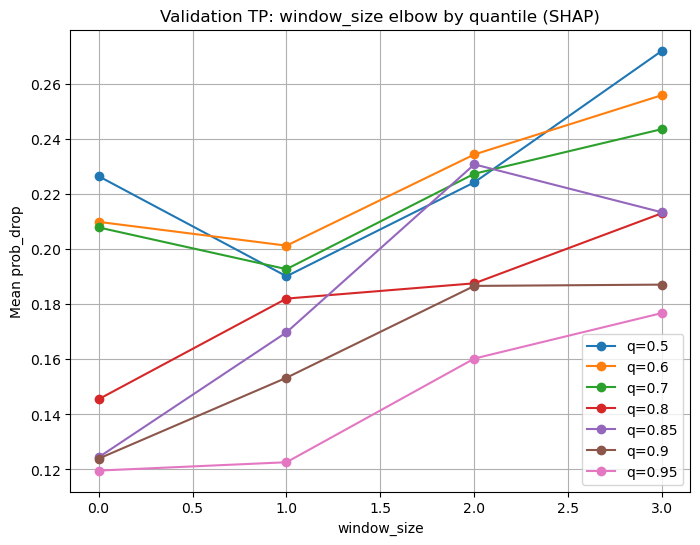

Saved plot: shap_results/validation_config_selection/shap_val_window_elbow_by_quantile.png


In [17]:
method_df = val_config_summary[
    val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for quantile in sorted(method_df["quantile"].unique()):
    subset = method_df[
        method_df["quantile"] == quantile
    ].sort_values("window_size")
    
    plt.plot(
        subset["window_size"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"q={quantile}"
    )

plt.xlabel("window_size")
plt.ylabel("Mean prob_drop")
plt.title("Validation TP: window_size elbow by quantile (SHAP)")
plt.grid(True)
plt.legend()

plot_path = val_output_dir / "shap_val_window_elbow_by_quantile.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

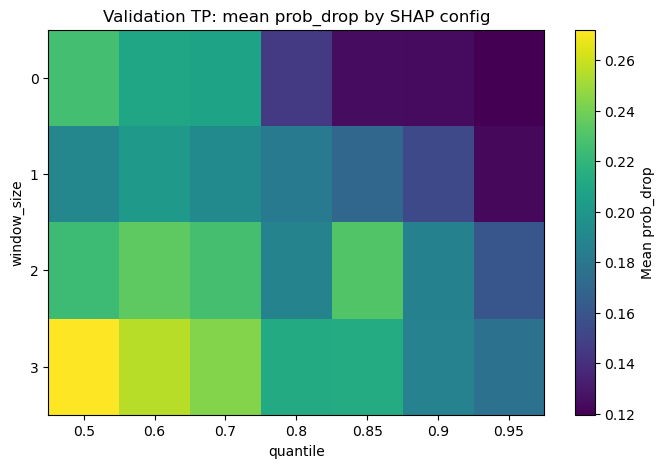

Saved plot: shap_results/validation_config_selection/shap_val_find_config_heatmap.png


quantile,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,
0,0.226388,0.209826,0.207803,0.145469,0.124390,0.123903,0.119574
1,0.190078,0.201194,0.192668,0.181986,0.169736,0.153261,0.122596
2,0.224161,0.234282,0.227289,0.187527,0.230685,0.186587,0.160226
3,0.271976,0.255835,0.243505,0.213002,0.213258,0.187052,0.176760


In [18]:
method_df = val_config_summary[
    val_config_summary["attribution_method"] == "shap"
].copy()

heatmap_data = method_df.pivot(
    index="window_size",
    columns="quantile",
    values="mean_prob_drop"
)

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean prob_drop")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("quantile")
plt.ylabel("window_size")
plt.title("Validation TP: mean prob_drop by SHAP config")

plot_path = val_output_dir / "shap_val_find_config_heatmap.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)
display(heatmap_data)

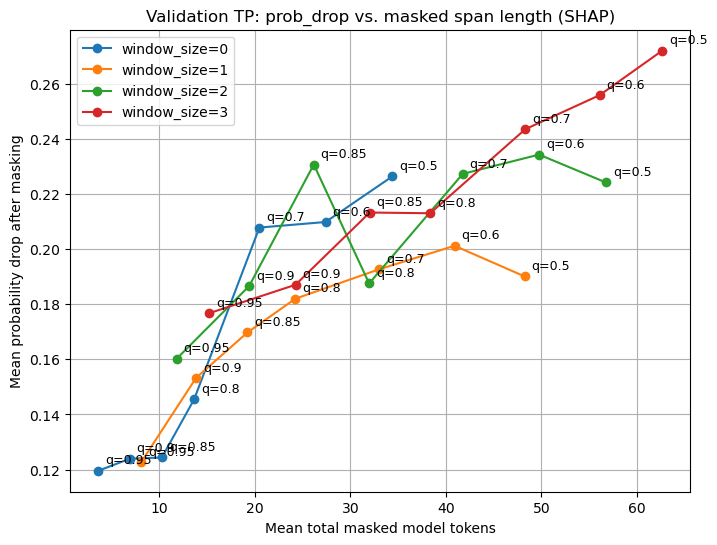

Saved plot: shap_results/validation_config_selection/shap_val_prob_drop_vs_mean_masked_tokens.png


In [19]:
method_df = val_config_summary[
    val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_total_masked_tokens"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_total_masked_tokens"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean total masked model tokens")
plt.ylabel("Mean probability drop after masking")
plt.title("Validation TP: prob_drop vs. masked span length (SHAP)")
plt.grid(True)
plt.legend()

plot_path = val_output_dir / "shap_val_prob_drop_vs_mean_masked_tokens.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

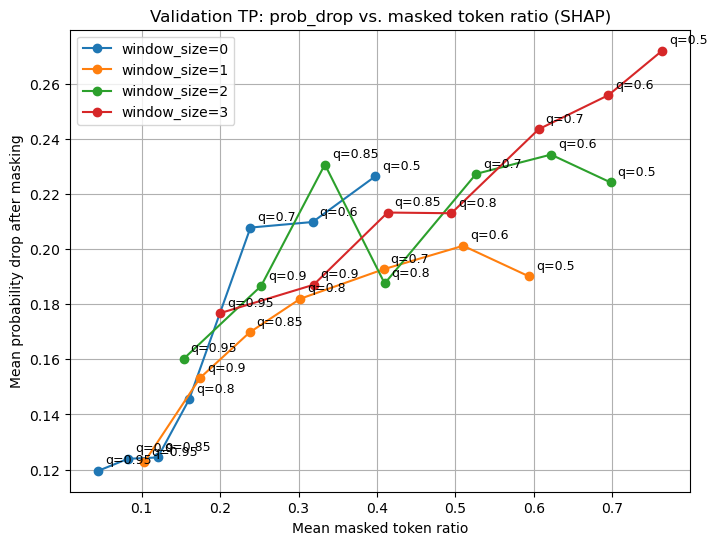

Saved plot: shap_results/validation_config_selection/shap_validation_prob_drop_vs_masked_token_ratio.png


In [20]:
method_df = val_config_summary[
    val_config_summary["attribution_method"] == "shap"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title("Validation TP: prob_drop vs. masked token ratio (SHAP)")
plt.grid(True)
plt.legend()

plot_path = val_output_dir / "shap_validation_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

# Test on simply choosing the best prob_drop

In [16]:
BEST_QUANTILE = 0.5
BEST_WINDOW_SIZE = 3

In [17]:
def highlight_spans(text, spans):
    """Highlight multiple character spans in one text."""
    text = str(text)
    
    if not spans:
        return html.escape(text)
    
    spans = sorted(spans, key=lambda x: x["char_start"])
    
    parts = []
    last_end = 0
    
    for span in spans:
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        if start < last_end:
            continue
        
        parts.append(html.escape(text[last_end:start]))
        parts.append(
            "<mark style='background-color:#ffe58a; padding:2px 4px; border-radius:4px;'>"
            + html.escape(text[start:end])
            + "</mark>"
        )
        last_end = end
    
    parts.append(html.escape(text[last_end:]))
    
    return "".join(parts)


def show_shap_example(result_df, index=0):
    """Display one SHAP result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attribution_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>logit_drop:</b> {float(row["logit_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

def show_builtin_shap_explanation(text, title=None):
    """
    Compute and display the built-in SHAP text visualization for one text.
    
    The visualization shows token/segment contributions to LABEL_1,
    where positive values support the inappropriate class and negative values
    work against it.
    """
    text = str(text)
    
    if title is not None:
        display(HTML(f"<h4>{html.escape(str(title))}</h4>"))
    
    shap_values = explainer_logits(
        [text],
        batch_size=SHAP_BATCH_SIZE
    )
    
    shap.plots.text(shap_values[0, :, INAPPROPRIATE_LABEL])
    
    return shap_values

## Final selected SHAP configuration

The final SHAP configuration is selected based on validation true positives.

The selected configuration is then applied to all splits:
- train
- validation
- test

This produces comparable argument-level and span-level outputs for downstream comparison with Integrated Gradients, attention-based spans, and random baselines.

In [ ]:
def run_final_shap_on_split(df, split_name):
    """
    Run the selected SHAP configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    results = run_shap_config_on_indices(
        df=df,
        matrix_positions=positions,
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_argument_level_df(results)
    span_df = build_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


train_results, train_argument_df, train_span_df = run_final_shap_on_split(
    train_df,
    "train"
)

val_results, val_argument_df, val_span_df = run_final_shap_on_split(
    val_df,
    "validation"
)

test_results, test_argument_df, test_span_df = run_final_shap_on_split(
    test_df,
    "test"
)

In [19]:
final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_segments_json,selected_tokens_json,merged_spans_json,was_truncated,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[18, 40]","[0, 98]","[79, 200]","[""people"", "" can"", ""t"", "" forced"", "" wear"", "",...","[""▁people"", ""▁can"", ""t"", ""▁forced"", ""▁wear"", ""...","[{""char_start"": 0, ""char_end"": 79, ""segment_st...",False,"people cant be forced to wear school uniforms,...",[MASK] wish whether they [MASK] the uniforms,None
1,1,train,2,Firefox vs internet explorer:,1,LABEL_1,0.998218,TP,True,False,...,"[18, 66]","[0, 134]","[93, 297]","[""That"", "" form"", "" of"", "" argument"", "" degrad...","[""▁That"", ""▁form"", ""▁of"", ""▁argument"", ""▁degra...","[{""char_start"": 0, ""char_end"": 93, ""segment_st...",False,"That form of argument degrades this forum, and...","[MASK] common denominator. This word, ""indispu...",None
2,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,0.969683,TN,False,False,...,"[4, 22, 42]","[0, 22, 142]","[18, 89, 166]","["""", ""I"", "" my"", "" She"", "" made"", "" mistake"", ...","[""▁I"", ""▁my"", ""▁She"", ""▁made"", ""▁mistake"", ""▁c...","[{""char_start"": 0, ""char_end"": 18, ""segment_st...",False,I wouldnt turn her in becuase she is my wife. ...,[MASK] in [MASK] If she trusted me by telling ...,None
3,3,train,4,If your spouse committed murder and he or she ...,1,LABEL_1,0.998705,TP,True,False,...,"[13, 32]","[0, 93]","[49, 143]","[""No"", "" I"", "" wouldn"", ""'"", ""t"", "" turn"", "" i...","[""▁No"", ""▁I"", ""▁wouldn"", ""'"", ""t"", ""▁turn"", ""▁...","[{""char_start"": 0, ""char_end"": 49, ""segment_st...",False,No I wouldn't turn in my spouse. Just because ...,[MASK] girl that i married killed someone does...,None
4,4,train,5,Tv is better than books:,1,LABEL_1,0.998405,TP,True,False,...,"[27, 35]","[0, 117]","[116, 145]","[""TV"", "" is"", "" terrible"", ""."", "" Except"", "" f...","[""▁TV"", ""▁is"", ""▁terrible"", ""."", ""▁Except"", ""▁...","[{""char_start"": 0, ""char_end"": 116, ""segment_s...",False,TV is terrible. Except for Spongebob maybe. Th...,[MASK]'[MASK] that.,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_model_tokens,n_segments,n_selected_tokens,n_selected_segments,selected_token_ratio,selected_segment_ratio,masked_token_ratio,was_truncated,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,17,17,0.404762,0.386364,0.880952,False,"people cant be forced to wear school uniforms,...",[MASK] wish whether they [MASK] the uniforms
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,42,44,17,17,0.404762,0.386364,0.880952,False,"people cant be forced to wear school uniforms,...",[MASK] wish whether they [MASK] the uniforms
2,1,train,2,Firefox vs internet explorer:,1,LABEL_1,TP,True,False,False,...,80,82,33,33,0.412500,0.402439,0.700000,False,"That form of argument degrades this forum, and...","[MASK] common denominator. This word, ""indispu..."
3,1,train,2,Firefox vs internet explorer:,1,LABEL_1,TP,True,False,False,...,80,82,33,33,0.412500,0.402439,0.700000,False,"That form of argument degrades this forum, and...","[MASK] common denominator. This word, ""indispu..."
4,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,TN,False,False,False,...,42,44,9,10,0.214286,0.227273,0.690476,False,I wouldnt turn her in becuase she is my wife. ...,[MASK] in [MASK] If she trusted me by telling ...


Final argument-level rows: 2191
Final span-level rows: 7342


In [20]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,truncation_rate
0,test,shap,3,0.5,438,0.025273,0.001404,0.470630,0.539823,0.461069,0.609589,0.394977,0.324201,0.590804,0.565531,3.433790,57.280822,0.663200,0.0
1,train,shap,3,0.5,1533,0.004564,0.000802,0.464221,0.375108,0.253919,0.564905,0.353555,0.272668,0.552141,0.547576,3.323549,56.111546,0.647851,0.0
2,validation,shap,3,0.5,220,-0.002464,0.000411,0.480002,0.314175,0.117277,0.536364,0.363636,0.290909,0.542075,0.544539,3.377273,54.404545,0.632261,0.0


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.330356,-0.198440,0.408416,-2.992503,-2.297977,0.179487,0.049638,0.379994,3.589744,45.717949,0.478198
1,test,FP,71,0.315375,0.256998,0.344136,3.350078,3.261875,0.873239,0.971585,0.656211,3.042254,55.957746,0.727444
2,test,TN,142,-0.322933,-0.066038,0.417684,-3.347356,-2.223669,0.197183,0.037216,0.360149,3.915493,53.514085,0.516783
3,test,TP,186,0.254938,0.035574,0.325736,3.175371,2.321453,0.913978,0.981555,0.726617,3.182796,63.086022,0.789249
4,train,FN,48,-0.272751,-0.144720,0.354767,-1.987637,-1.885440,0.250000,0.115297,0.388048,3.145833,43.791667,0.554453
5,train,FP,48,0.228896,0.061546,0.373379,2.262538,1.503962,0.750000,0.915789,0.686893,2.791667,52.833333,0.749189
6,train,TN,652,-0.308518,-0.079739,0.395186,-3.239210,-2.255373,0.164110,0.030158,0.338676,3.682515,48.093558,0.510529
7,train,TP,785,0.267841,0.027367,0.341784,3.406129,2.411394,0.905732,0.990161,0.722320,3.068790,63.724841,0.761422
8,validation,FN,36,-0.325608,-0.165496,0.404195,-2.922009,-1.369270,0.166667,0.040581,0.366189,3.583333,49.111111,0.481782
9,validation,FP,30,0.307485,0.114049,0.358815,2.913909,2.432968,0.833333,0.968823,0.661338,3.166667,53.500000,0.705871


In [21]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_logit_drop=("logit_drop", "mean"),
        median_logit_drop=("logit_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,truncation_rate
0,shap,3,0.5,438,0.025273,0.001404,0.47063,0.539823,0.461069,0.609589,0.394977,0.324201,0.590804,0.565531,3.43379,57.280822,0.6632,0.0


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_logit_drop,median_logit_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.330356,-0.198440,0.408416,-2.992503,-2.297977,0.179487,0.049638,0.379994,3.589744,45.717949,0.478198
1,FP,71,0.315375,0.256998,0.344136,3.350078,3.261875,0.873239,0.971585,0.656211,3.042254,55.957746,0.727444
2,TN,142,-0.322933,-0.066038,0.417684,-3.347356,-2.223669,0.197183,0.037216,0.360149,3.915493,53.514085,0.516783
3,TP,186,0.254938,0.035574,0.325736,3.175371,2.321453,0.913978,0.981555,0.726617,3.182796,63.086022,0.789249


In [22]:
def make_json_serializable(obj):
    """Convert numpy and pandas scalar types to JSON-serializable Python types."""
    if isinstance(obj, dict):
        return {str(k): make_json_serializable(v) for k, v in obj.items()}
    
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    
    if isinstance(obj, np.integer):
        return int(obj)
    
    if isinstance(obj, np.floating):
        return float(obj)
    
    if isinstance(obj, np.bool_):
        return bool(obj)
    
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    
    if obj is pd.NA:
        return None
    
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    
    return obj

In [23]:
final_output_dir = OUTPUT_DIR / "shap_results_diff_config"
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"shap_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"shap_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"shap_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"shap_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"shap_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"shap_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = train_results + val_results + test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
shap_results/shap_results_diff_config/shap_final_all_splits_q0.5_window3_argument_level.csv
shap_results/shap_results_diff_config/shap_final_all_splits_q0.5_window3_span_level.csv
shap_results/shap_results_diff_config/shap_final_all_splits_q0.5_window3_overall_summary.csv
shap_results/shap_results_diff_config/shap_final_all_splits_q0.5_window3_confusion_summary.csv
shap_results/shap_results_diff_config/shap_final_test_q0.5_window3_summary.csv
shap_results/shap_results_diff_config/shap_final_all_splits_q0.5_window3_argument_level.jsonl


In [24]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_shap_example(tmp, index=i)

In [25]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_shap_example(tmp_low, index=i)

In [26]:
best_test_for_builtin = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

for i, row in best_test_for_builtin.iterrows():
    title = (
        f"Test example {i + 1} | "
        f"global_row_id={row['global_row_id']} | "
        f"post_id={row['post_id']} | "
        f"prob_drop={row['prob_drop']:.4f} | "
        f"logit_drop={row['logit_drop']:.4f}"
    )
    
    show_shap_example(best_test_for_builtin, index=i)
    show_builtin_shap_explanation(row["text"], title=title)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.63s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.75s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.69s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.69s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.47s/it]               


In [27]:
weak_test_for_builtin = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .head(5)
    .reset_index(drop=True)
)

for i, row in weak_test_for_builtin.iterrows():
    title = (
        f"Weak test example {i + 1} | "
        f"global_row_id={row['global_row_id']} | "
        f"post_id={row['post_id']} | "
        f"prob_drop={row['prob_drop']:.4f} | "
        f"logit_drop={row['logit_drop']:.4f}"
    )
    
    show_shap_example(weak_test_for_builtin, index=i)
    show_builtin_shap_explanation(row["text"], title=title)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.61s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.33s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.35s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.40s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.32s/it]               
